In [1]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from matplotlib.colors import LogNorm
from tqdm import tqdm
from qutip.qip.operations import rz, cz_gate
import cmath
from sympy import symbols
import utils_2Q_gate_zp as ut
import scipy as sp
from joblib import Parallel, delayed
import pandas as pd
import itertools
from qutip.qip.operations import rz, cz_gate, cnot, rx, hadamard_transform

In [ ]:
f_False_1000 = np.array([
-0.31308179, -0.3807945, -0.45595414, -0.53517053 ,
-0.62362769, -0.72035237, -0.83263802, -0.96721885 ,
-1.13427921, -1.32287436, -1.54607246, -1.7622428 ,
-1.91027038, -2.05780752, -2.25166149, -2.40898086 ,
-2.53251749, -2.64483378, -2.76168067, -2.84286097 ,
-2.91236387, -2.98764623, -2.618628 ,
])
f_short200 = np.array([
-0.31416804, -0.37953706, -0.45328995, -0.53253985 ,
-0.62055602, -0.71817058, -0.82997394, -0.96321383 ,
-1.12520033, -1.30663352, -1.51335307, -1.70079442 ,
-1.84956121, -2.00077611, -2.20239633, -2.39116377 ,
-2.52671861, -2.65070337, -2.76713919, -2.84964821 ,
-2.92073169, -2.99583451, -2.62592689 ,
])
para = np.array([
[30.01162, 0.10169, 0.044983, -0.009811, -0.009766] ,
[40.014074, 0.085444, 0.03794, -0.00987, -0.009874] ,
[50.005145, 0.078375, 0.034478, -0.009941, -0.009926] ,
[60.017067, 0.069601, 0.032036, -0.00987, -0.009726] ,
[69.995489, 0.063351, 0.029729, -0.009859, -0.009981] ,
[80.00902, 0.057964, 0.029654, -0.009943, -0.009989] ,
[90.007516, 0.054955, 0.028574, -0.009961, -0.009968] ,
[100.009188, 0.051464, 0.028152, -0.00999, -0.009967] ,
[110.007023, 0.048962, 0.027303, -0.01, -0.00999] ,
[119.996501, 0.045946, 0.026419, -0.009876, -0.009588] ,
[129.989151, 0.043855, 0.02623, -0.009997, -0.00958] ,
[140.008976, 0.041195, 0.025523, -0.009916, -0.009373] ,
[149.996866, 0.039078, 0.024359, -0.009107, -0.008681] ,
[160.000133, 0.036595, 0.022959, -0.008237, -0.007826] ,
[169.993992, 0.034622, 0.02211, -0.007681, -0.007266] ,
[179.996641, 0.032821, 0.02095, -0.006902, -0.006534] ,
[189.997344, 0.030915, 0.019755, -0.006194, -0.005848] ,
[200.001513, 0.029121, 0.018721, -0.005572, -0.005265] ,
[209.996351, 0.02774, 0.017771, -0.005024, -0.004777] ,
[219.997562, 0.026349, 0.016887, -0.00455, -0.004302] ,
[230.001715, 0.025067, 0.016064, -0.00409, -0.003877] ,
[239.989977, 0.023957, 0.015387, -0.003744, -0.003546] ,
[249.995289, 0.037669, 0.024993, -0.001763, -0.001343] ,
])

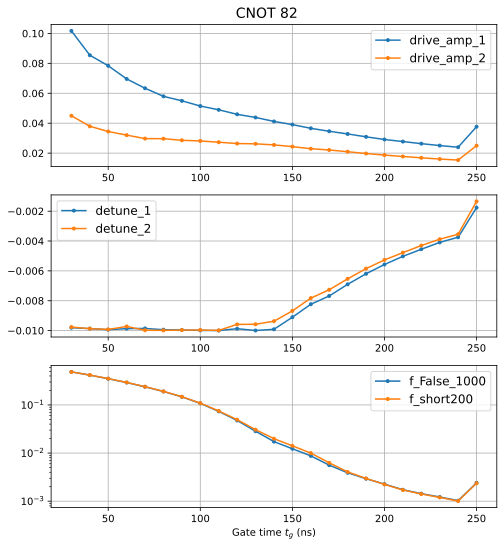

In [9]:
fig, ax = plt.subplots(figsize=(8,8), nrows=3)
fig.suptitle('CNOT 82', fontsize=14)
fig.subplots_adjust(top=0.95)
ax[0].plot(para[:,0], para[:,1], '.-',  label=r'drive_amp_1')
ax[0].plot(para[:,0], para[:,2], '.-',  label=r'drive_amp_2')
ax[1].plot(para[:,0], para[:,3], '.-',  label=r'detune_1')
ax[1].plot(para[:,0], para[:,4], '.-',  label=r'detune_2')
ax[2].plot(para[:,0], 10**f_False_1000, '.-',  label=r'f_False_1000')
ax[2].plot(para[:,0], 10**f_short200, '.-',  label=r'f_short200')

plt.xlabel('Gate time $t_g$ (ns)')
ax[2].set_yscale('log')
for i in range(3):
    ax[i].legend(loc='best', fontsize=12)
    ax[i].grid()

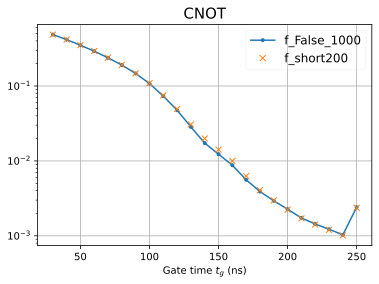

In [3]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(para[:,0], 10**f_False_1000, '.-',  label=r'f_False_1000')
ax.plot(para[:,0], 10**f_short200, 'x',  label=r'f_short200')

plt.yscale('log')
# plt.ylim(3e-7, 6e-1)
plt.xlabel('Gate time $t_g$ (ns)')
plt.title(r'CNOT', fontsize=15)
plt.grid()
legend = plt.legend(loc='best', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent